In [3]:
import pandas as pd
import numpy as np

train=pd.read_csv('train.csv')
print("Dataset shape:", train.shape)

train.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Check missing values
missing_values = train.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


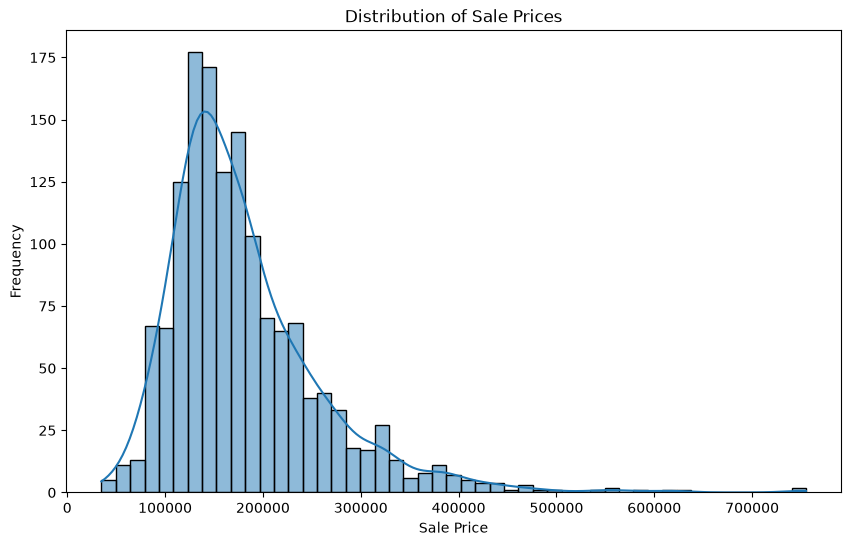

In [6]:
# Distribution of the target variable: SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

## Feature Selection Discussion

The target variable for this project is **SalePrice**, which represents the final sale price of each house.

The following features are selected as potential predictors because they describe important characteristics of a property:

- **OverallQual** – overall material and finish quality of the house.
- **GrLivArea** – above-ground living area in square feet.
- **GarageCars** – number of cars that can be accommodated in the garage.
- **GarageArea** – garage size in square feet.
- **TotalBsmtSF** – total basement area.
- **1stFlrSF** – first-floor area.
- **YearBuilt** – original construction year.
- **FullBath** – number of full bathrooms.
- **TotRmsAbvGrd** – total number of rooms above ground.
- **Neighborhood** – location of the property, which can influence house prices.

These features are selected because house quality, size, age, facilities, and location are likely to have a meaningful relationship with **SalePrice**.

Categorical features such as **Neighborhood** will be converted into numerical form using **One-Hot Encoding** before training the Linear Regression model.

In [7]:
# Select features for the model

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd",
    "Neighborhood"
]

X = train[features].copy()
y = train["SalePrice"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (1460, 10)
Target shape: (1460,)


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,YearBuilt,FullBath,TotRmsAbvGrd,Neighborhood
0,7,1710,2,548,856,856,2003,2,8,CollgCr
1,6,1262,2,460,1262,1262,1976,2,6,Veenker
2,7,1786,2,608,920,920,2001,2,6,CollgCr
3,7,1717,3,642,756,961,1915,1,7,Crawfor
4,8,2198,3,836,1145,1145,2000,2,9,NoRidge


In [8]:
# Check missing values in selected features

X.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
YearBuilt       0
FullBath        0
TotRmsAbvGrd    0
Neighborhood    0
dtype: int64

In [9]:
# One-Hot Encode the categorical feature

X_encoded = pd.get_dummies(
    X,
    columns=["Neighborhood"],
    drop_first=True,
    dtype=int
)

print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()

Encoded feature shape: (1460, 33)


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,YearBuilt,FullBath,TotRmsAbvGrd,Neighborhood_Blueste,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,7,1710,2,548,856,856,2003,2,8,0,...,0,0,0,0,0,0,0,0,0,0
1,6,1262,2,460,1262,1262,1976,2,6,0,...,0,0,0,0,0,0,0,0,0,1
2,7,1786,2,608,920,920,2001,2,6,0,...,0,0,0,0,0,0,0,0,0,0
3,7,1717,3,642,756,961,1915,1,7,0,...,0,0,0,0,0,0,0,0,0,0
4,8,2198,3,836,1145,1145,2000,2,9,0,...,1,0,0,0,0,0,0,0,0,0


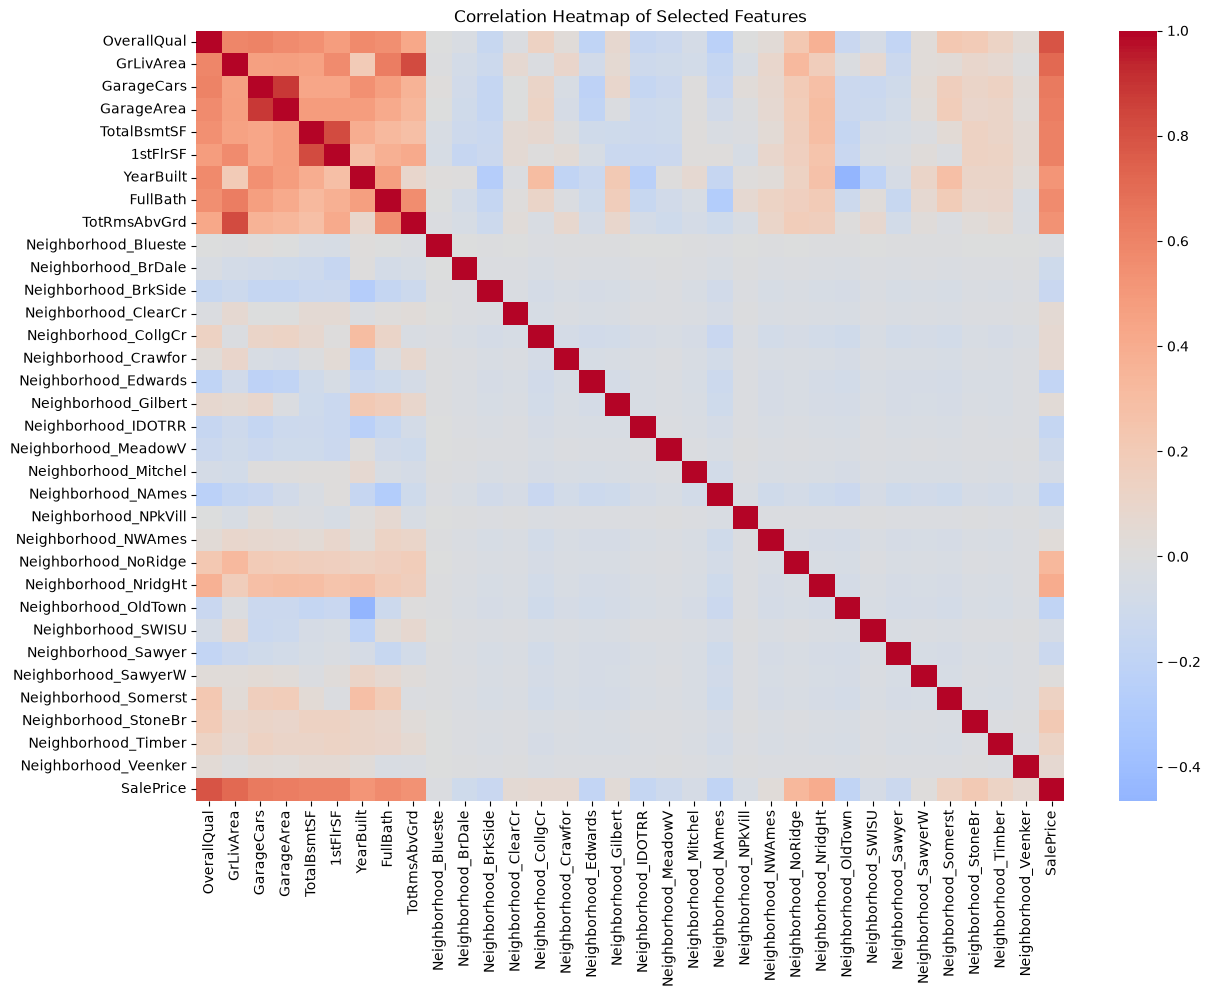

In [10]:
 # Correlation heatmap

correlation = X_encoded.copy()
correlation["SalePrice"] = y

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 33)
Testing features: (292, 33)
Training target: (1168,)
Testing target: (292,)


In [13]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 1335982644.2051773
Root Mean Squared Error (RMSE): 36551.09634751299
R² Score: 0.8258245336484704


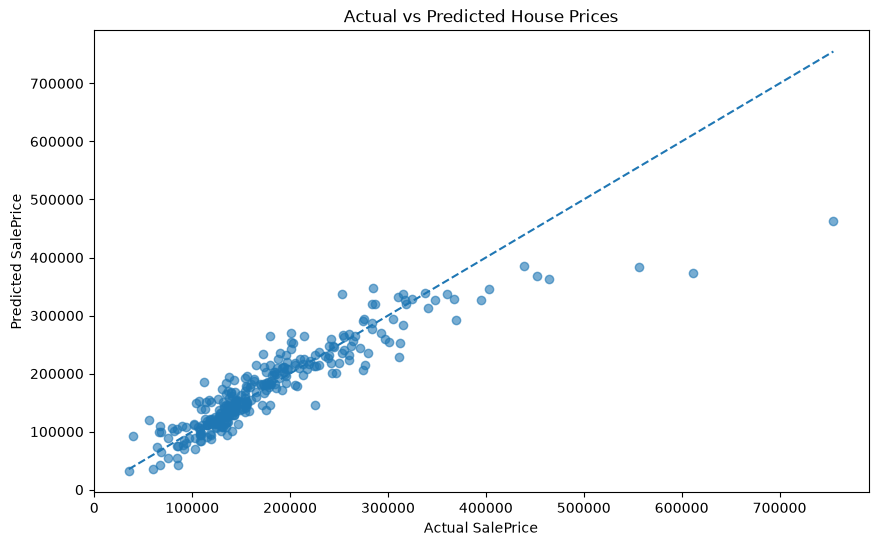

In [15]:
# Actual vs Predicted Prices

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

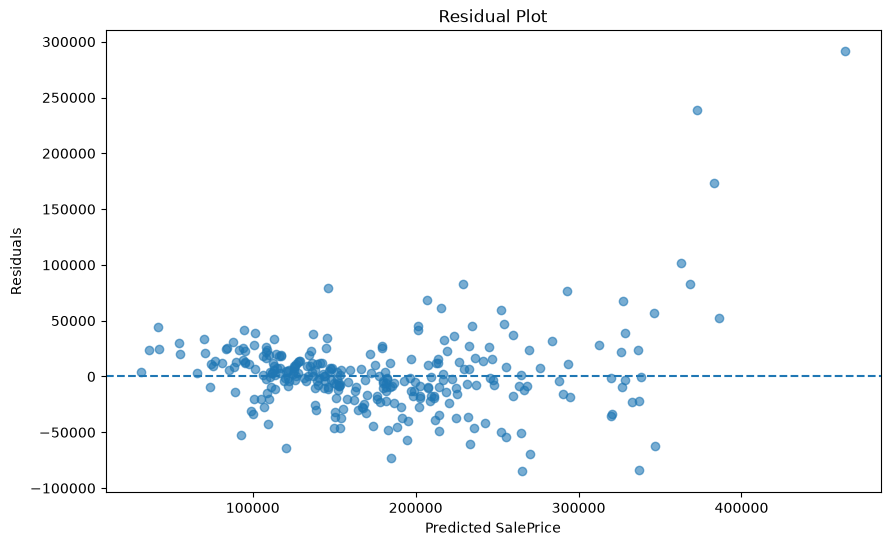

In [16]:
# Residual plot

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.show()

In [17]:
# Coefficient analysis

coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
})

# Sort by coefficient
coefficients_sorted = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients_sorted

,Feature,Coefficient
30,Neighborhood_StoneBr,74191.271463
23,Neighborhood_NoRidge,71252.875450
24,Neighborhood_NridgHt,69775.958103
32,Neighborhood_Veenker,62887.205144
12,Neighborhood_ClearCr,50969.971174
14,Neighborhood_Crawfor,46239.518934
31,Neighborhood_Timber,37026.207482
29,Neighborhood_Somerst,29556.086708
11,Neighborhood_BrkSide,23563.901029
13,Neighborhood_CollgCr,22305.590688


In [19]:
# Show the strongest positive and negative coefficients

print("Top 10 Positive Coefficients:")
display(coefficients_sorted.head(10))

print("\nTop 10 Negative Coefficients:")
display(coefficients_sorted.tail(10).sort_values("Coefficient"))

Top 10 Positive Coefficients:


,Feature,Coefficient
30,Neighborhood_StoneBr,74191.271463
23,Neighborhood_NoRidge,71252.875450
24,Neighborhood_NridgHt,69775.958103
32,Neighborhood_Veenker,62887.205144
12,Neighborhood_ClearCr,50969.971174
14,Neighborhood_Crawfor,46239.518934
31,Neighborhood_Timber,37026.207482
29,Neighborhood_Somerst,29556.086708
11,Neighborhood_BrkSide,23563.901029
13,Neighborhood_CollgCr,22305.590688



Top 10 Negative Coefficients:


,Feature,Coefficient
10,Neighborhood_BrDale,-12866.082447
9,Neighborhood_Blueste,-10193.513399
7,FullBath,-3113.657989
3,GarageArea,11.872385
4,TotalBsmtSF,12.008601
5,1stFlrSF,13.015172
1,GrLivArea,41.153438
6,YearBuilt,301.637078
8,TotRmsAbvGrd,1625.007580
21,Neighborhood_NPkVill,3586.846282


In [20]:
# Bonus: Compare Linear Regression with Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train Ridge Regression model
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test)

# Evaluate Ridge Regression
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("Mean Squared Error (MSE):", ridge_mse)
print("Root Mean Squared Error (RMSE):", ridge_rmse)
print("R² Score:", ridge_r2)

# Compare with Linear Regression
print("\nLinear Regression Results")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Ridge Regression Results
Mean Squared Error (MSE): 1353371413.9936643
Root Mean Squared Error (RMSE): 36788.196666779746
R² Score: 0.8235575153602268

Linear Regression Results
Mean Squared Error (MSE): 1335982644.2051773
Root Mean Squared Error (RMSE): 36551.09634751299
R² Score: 0.8258245336484704


### Ridge Regression vs Linear Regression

The Linear Regression model achieved an R² score of approximately 0.826, while the Ridge Regression model achieved an R² score of approximately 0.824.

The Linear Regression model also produced slightly lower MSE and RMSE values on the test set. This indicates that, for this dataset and the selected Ridge regularization parameter (alpha = 10), the regularized model did not improve the test-set performance.

Ridge Regression is still useful because regularization can help reduce the impact of large coefficients and can improve model stability when features are highly correlated.

Overall, both models explain approximately 82% of the variation in house prices, showing that the selected features provide substantial predictive information.

# Final Project Summary

## House Price Prediction

This project developed a machine learning model to predict house sale prices using the Ames Housing dataset.

### Key Steps
- Performed exploratory data analysis and descriptive statistics.
- Analyzed missing values and handled them appropriately.
- Encoded categorical variables for machine learning.
- Selected relevant features for prediction.
- Split the dataset into training and testing sets using an 80/20 split.
- Trained a Linear Regression model.
- Evaluated the model using MSE, RMSE, and R² Score.
- Visualized actual vs predicted house prices.
- Analyzed the strongest positive and negative model coefficients.
- Compared Linear Regression with Ridge Regression.

### Model Performance
The Linear Regression model achieved an R² score of approximately 0.826 on the test set.

The Ridge Regression model achieved an R² score of approximately 0.824.

Both models explain approximately 82% of the variation in house prices on the test data.

### Conclusion
The analysis demonstrates that the selected housing features provide substantial predictive information about house sale prices. Linear Regression provided slightly better test-set performance than the selected Ridge Regression model for this dataset.